Adding GDP

In [4]:
# RF_v4: Random Forest with storm/weather/spatial features + county GDP.
# Unit: one row per event-county window.
# Target: t90, from event_start to last downward crossing of outage threshold.
# Evaluation: leave-one-storm-out cross-validation, using global MAE/RMSE.

import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [5]:
rf_v3_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_rf_v3.csv"

event_df = pd.read_csv(rf_v3_path)

event_df["CountyFIPS"] = event_df["CountyFIPS"].astype(str).str.zfill(5)

if "event_start" not in event_df.columns:
    event_df["event_start"] = pd.to_datetime(event_df["event_id"].str.split("_").str[1])
else:
    event_df["event_start"] = pd.to_datetime(event_df["event_start"])

event_df["year"] = event_df["event_start"].dt.year

print("Event dataset:", event_df.shape)
print(event_df.columns.tolist())
print(event_df[["event_id", "CountyFIPS", "storm", "year", "t90"]].head())

Event dataset: (90, 17)
['event_id', 'storm', 'CountyFIPS', 't90', 't90_censored', 'max_gust', 'mean_gust_7d', 'total_precip_7d', 'pressure_min_7d', 'max_customers_tracked', 'county_pop', 'event_start', 'min_dist_to_storm_km', 'matched_ibtracs_storm', 'storm_max_wind_center_in_conus_mps', 'storm_max_wind_near_conus_mps', 'year']
                            event_id CountyFIPS          storm  year  \
0  2017212N28275_2017-07-30 21:00:00      12075  2017212N28275  2017   
1  2017242N16333_2017-09-09 19:00:00      12037  2017242N16333  2017   
2  2017242N16333_2017-09-09 20:00:00      12067  2017242N16333  2017   
3  2017242N16333_2017-09-09 21:00:00      12013  2017242N16333  2017   
4  2017242N16333_2017-09-09 22:00:00      12075  2017242N16333  2017   

          t90  
0    1.885185  
1  120.406155  
2  186.802564  
3   52.651220  
4  170.764203  


In [6]:
# -----------------------
# Load manually downloaded BEA county GDP data
# -----------------------

gdp_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\CAGDP1\CAGDP1_FL_2001_2024.csv"

gdp_raw = pd.read_csv(gdp_path)

print("Raw GDP shape:", gdp_raw.shape)
print(gdp_raw.head())
print(gdp_raw.columns.tolist())

Raw GDP shape: (208, 32)
    GeoFIPS      GeoName  Region TableName  LineCode IndustryClassification  \
0   "12000"      Florida     5.0    CAGDP1       1.0                    ...   
1   "12000"      Florida     5.0    CAGDP1       2.0                    ...   
2   "12000"      Florida     5.0    CAGDP1       3.0                    ...   
3   "12001"  Alachua, FL     5.0    CAGDP1       1.0                    ...   
4   "12001"  Alachua, FL     5.0    CAGDP1       2.0                    ...   

                                         Description  \
0      Real GDP (thousands of chained 2017 dollars)    
1          Chain-type quantity indexes for real GDP    
2  Current-dollar GDP (thousands of current dolla...   
3      Real GDP (thousands of chained 2017 dollars)    
4          Chain-type quantity indexes for real GDP    

                                Unit          2001          2002  ...  \
0  Thousands of chained 2017 dollars  7.146380e+08  7.462528e+08  ...   
1                

In [7]:
# -----------------------
# Clean + reshape BEA GDP from wide to long
# -----------------------
# Your downloaded file has:
# - GeoFIPS
# - GeoName
# - year columns: 2001, 2002, ..., 2024
# - Unit = "Thousands of chained 2017 dollars"
#
# We convert it to:
# CountyFIPS | year | county_gdp_real_2017_thousand_dollars
#
# Then convert to dollars:
# county_gdp_real_2017_dollars = value * 1000

gdp = gdp_raw.copy()

# Standardize FIPS.
gdp["CountyFIPS"] = (
    gdp["GeoFIPS"]
    .astype(str)
    .str.replace('"', "", regex=False)
    .str.strip()
    .str.zfill(5)
)

# Keep only county rows, not the state total.
# Florida state total is 12000. County rows are 12001, 12003, etc.
gdp = gdp[gdp["CountyFIPS"].str.startswith("12")].copy()
gdp = gdp[gdp["CountyFIPS"] != "12000"].copy()

# Identify year columns.
year_cols = [c for c in gdp.columns if str(c).isdigit()]

print("Year columns found:", year_cols[:5], "...", year_cols[-5:])

# Wide -> long.
gdp_long = gdp.melt(
    id_vars=["CountyFIPS", "GeoName", "Description", "Unit"],
    value_vars=year_cols,
    var_name="year",
    value_name="county_gdp_real_2017_thousand_dollars"
)

gdp_long["year"] = gdp_long["year"].astype(int)

# Clean numeric GDP values.
gdp_long["county_gdp_real_2017_thousand_dollars"] = (
    gdp_long["county_gdp_real_2017_thousand_dollars"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

gdp_long["county_gdp_real_2017_thousand_dollars"] = pd.to_numeric(
    gdp_long["county_gdp_real_2017_thousand_dollars"],
    errors="coerce"
)

# Convert thousands of chained 2017 dollars -> chained 2017 dollars.
gdp_long["county_gdp_real_2017_dollars"] = (
    gdp_long["county_gdp_real_2017_thousand_dollars"] * 1000
)

gdp_clean = gdp_long[
    ["CountyFIPS", "year", "county_gdp_real_2017_dollars"]
].dropna().copy()

print("Clean GDP shape:", gdp_clean.shape)
print(gdp_clean.head())
print(gdp_clean["year"].min(), gdp_clean["year"].max())

Year columns found: ['2001', '2002', '2003', '2004', '2005'] ... ['2020', '2021', '2022', '2023', '2024']
Clean GDP shape: (4824, 3)
  CountyFIPS  year  county_gdp_real_2017_dollars
0      12001  2001                  9.994813e+09
1      12001  2001                  7.554300e+04
2      12001  2001                  6.969759e+09
3      12003  2001                  4.682010e+08
4      12003  2001                  7.046500e+04
2001 2024


In [8]:
# -----------------------
# Merge GDP onto event_df by county-year
# -----------------------

# Ensure event year exists.
if "event_start" not in event_df.columns:
    event_df["event_start"] = pd.to_datetime(event_df["event_id"].str.split("_").str[1])
else:
    event_df["event_start"] = pd.to_datetime(event_df["event_start"])

event_df["year"] = event_df["event_start"].dt.year
event_df["CountyFIPS"] = event_df["CountyFIPS"].astype(str).str.zfill(5)

event_df = event_df.merge(
    gdp_clean,
    on=["CountyFIPS", "year"],
    how="left"
)

print("Missing GDP rows:", event_df["county_gdp_real_2017_dollars"].isna().sum())

if event_df["county_gdp_real_2017_dollars"].isna().any():
    print(
        event_df.loc[
            event_df["county_gdp_real_2017_dollars"].isna(),
            ["event_id", "CountyFIPS", "year", "storm"]
        ].drop_duplicates()
    )

# GDP per capita.
event_df["county_gdp_real_2017_per_capita"] = (
    event_df["county_gdp_real_2017_dollars"] / event_df["county_pop"]
)

print(event_df[[
    "CountyFIPS",
    "year",
    "county_pop",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita"
]].head())

print("\nGDP summary:")
print(event_df[[
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita"
]].describe())

Missing GDP rows: 0
  CountyFIPS  year  county_pop  county_gdp_real_2017_dollars  \
0      12075  2017       45260                   922164000.0   
1      12075  2017       45260                      100000.0   
2      12075  2017       45260                   922164000.0   
3      12037  2017       12498                   337899000.0   
4      12037  2017       12498                      100000.0   

   county_gdp_real_2017_per_capita  
0                     20374.812196  
1                         2.209456  
2                     20374.812196  
3                     27036.245799  
4                         8.001280  

GDP summary:
       county_gdp_real_2017_dollars  county_gdp_real_2017_per_capita
count                  2.700000e+02                       270.000000
mean                   9.494248e+09                     22742.908694
std                    2.355733e+10                     19928.278684
min                    9.649000e+04                         0.037399
25%           

In [9]:
save_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_rf_v4_gdp.csv"

event_df.to_csv(save_path, index=False)

print("Saved RF_v4 dataset to:")
print(save_path)
print(event_df.shape)

Saved RF_v4 dataset to:
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_rf_v4_gdp.csv
(270, 19)


In [10]:
# -----------------------
# RF_v4 feature set
# -----------------------
# Deliberately excluded:
# - max_customers_tracked: noisy / unreliable reporting variable
# - CountyFIPS: tested separately before; did not materially improve performance
#
# Added:
# - county_gdp_current_dollars: absolute local economic scale
# - county_gdp_per_capita: local economic intensity / wealth proxy

features_v4 = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

target_col = "t90"
group_col = "storm"

X = event_df[features_v4].copy()
y = event_df[target_col].copy()
groups = event_df[group_col].copy()

print("Missing values by feature:")
print(X.isna().sum())

print("\nFeature preview:")
print(X.head())

Missing values by feature:
max_gust                           0
mean_gust_7d                       0
total_precip_7d                    0
pressure_min_7d                    0
county_pop                         0
min_dist_to_storm_km               0
storm_max_wind_near_conus_mps      0
county_gdp_real_2017_dollars       0
county_gdp_real_2017_per_capita    0
dtype: int64

Feature preview:
    max_gust  mean_gust_7d  total_precip_7d  pressure_min_7d  county_pop  \
0  12.601287      7.421799        67.413998      1009.864246       45260   
1  12.601287      7.421799        67.413998      1009.864246       45260   
2  12.601287      7.421799        67.413998      1009.864246       45260   
3  27.279316     12.005697        92.750718       995.318712       12498   
4  27.279316     12.005697        92.750718       995.318712       12498   

   min_dist_to_storm_km  storm_max_wind_near_conus_mps  \
0            201.493105                       25.72220   
1            201.493105             

In [11]:
preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), features_v4)
])

model_v4 = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=3,
        random_state=42
    ))
])

In [12]:
logo = LeaveOneGroupOut()

def evaluate_logo_global(model, X, y, groups):
    preds = np.full(len(y), np.nan)
    fold_rows = []

    for i, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        test_storm = groups.iloc[test_idx].iloc[0]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        preds[test_idx] = y_pred

        fold_rows.append({
            "fold": i,
            "storm": test_storm,
            "n": len(test_idx),
            "mae_diagnostic_per_storm": mean_absolute_error(y_test, y_pred),
            "rmse_diagnostic_per_storm": np.sqrt(mean_squared_error(y_test, y_pred)),
        })

    fold_df = pd.DataFrame(fold_rows)

    global_mae = mean_absolute_error(y, preds)
    global_rmse = np.sqrt(mean_squared_error(y, preds))

    return preds, fold_df, global_mae, global_rmse

pred_v4, fold_v4, mae_v4, rmse_v4 = evaluate_logo_global(model_v4, X, y, groups)

print("RF_v4 global metrics:")
print("Global MAE:", mae_v4)
print("Global RMSE:", rmse_v4)

print("\nPer-storm diagnostics:")
print(fold_v4.sort_values("mae_diagnostic_per_storm", ascending=False))

RF_v4 global metrics:
Global MAE: 104.22760207359599
Global RMSE: 129.66903730884076

Per-storm diagnostics:
   fold          storm    n  mae_diagnostic_per_storm  \
2     3  2018280N18273   42                147.191002   
1     2  2017242N16333  147                113.135547   
6     7  2022263N10313   57                 78.842555   
0     1  2017212N28275    3                 64.420178   
5     6  2021222N14301    9                 33.459141   
3     4  2020256N25281    9                 32.721768   
4     5  2021182N09317    3                 15.196934   

   rmse_diagnostic_per_storm  
2                 196.605921  
1                 127.012827  
6                  94.332067  
0                  64.420247  
5                  35.001040  
3                  38.737874  
4                  15.197070  


^ Global MAE of 104 is an improvement!

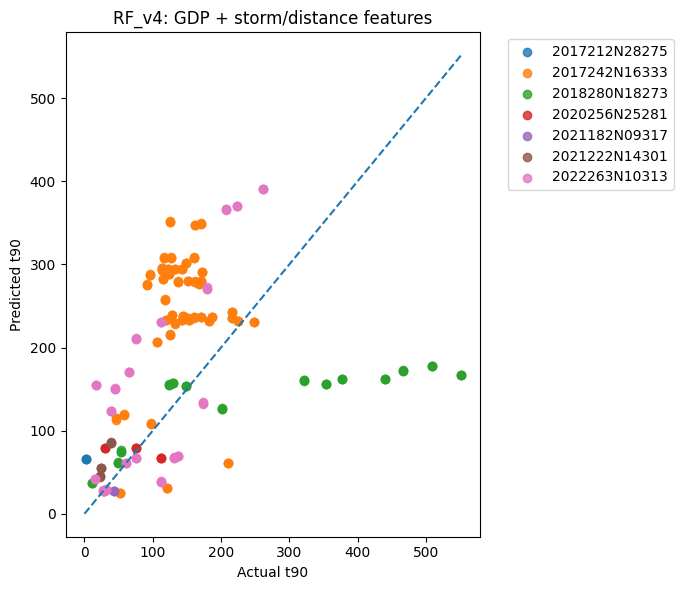

In [13]:
def plot_scatter_by_storm(preds, title):
    plt.figure(figsize=(7, 6))

    for storm in event_df["storm"].unique():
        s = event_df["storm"] == storm
        plt.scatter(
            event_df.loc[s, "t90"],
            preds[s],
            label=storm,
            alpha=0.8
        )

    m = max(event_df["t90"].max(), np.nanmax(preds))
    plt.plot([0, m], [0, m], "--")

    plt.xlabel("Actual t90")
    plt.ylabel("Predicted t90")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_scatter_by_storm(pred_v4, "RF_v4: GDP + storm/distance features")

pressure_min_7d                    0.358669
storm_max_wind_near_conus_mps      0.259341
min_dist_to_storm_km               0.137088
mean_gust_7d                       0.106589
max_gust                           0.104745
total_precip_7d                    0.021459
county_pop                         0.009046
county_gdp_real_2017_dollars       0.001741
county_gdp_real_2017_per_capita    0.001322
dtype: float64


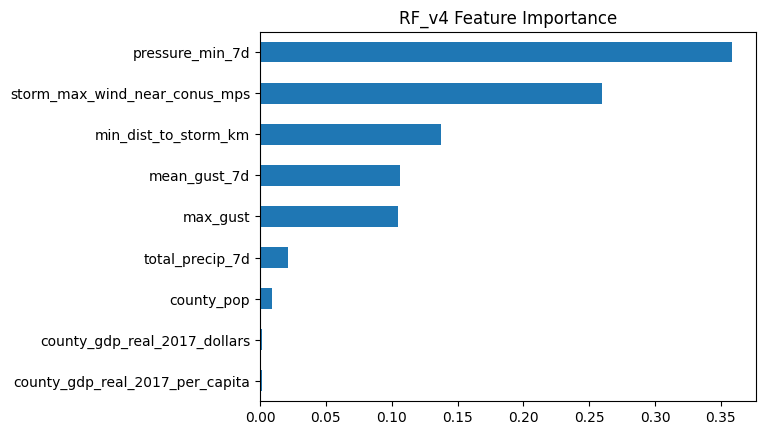

In [14]:
rf_model = model_v4.named_steps["rf"]

feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=features_v4
).sort_values(ascending=False)

print(feat_imp)

feat_imp.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("RF_v4 Feature Importance")
plt.show()

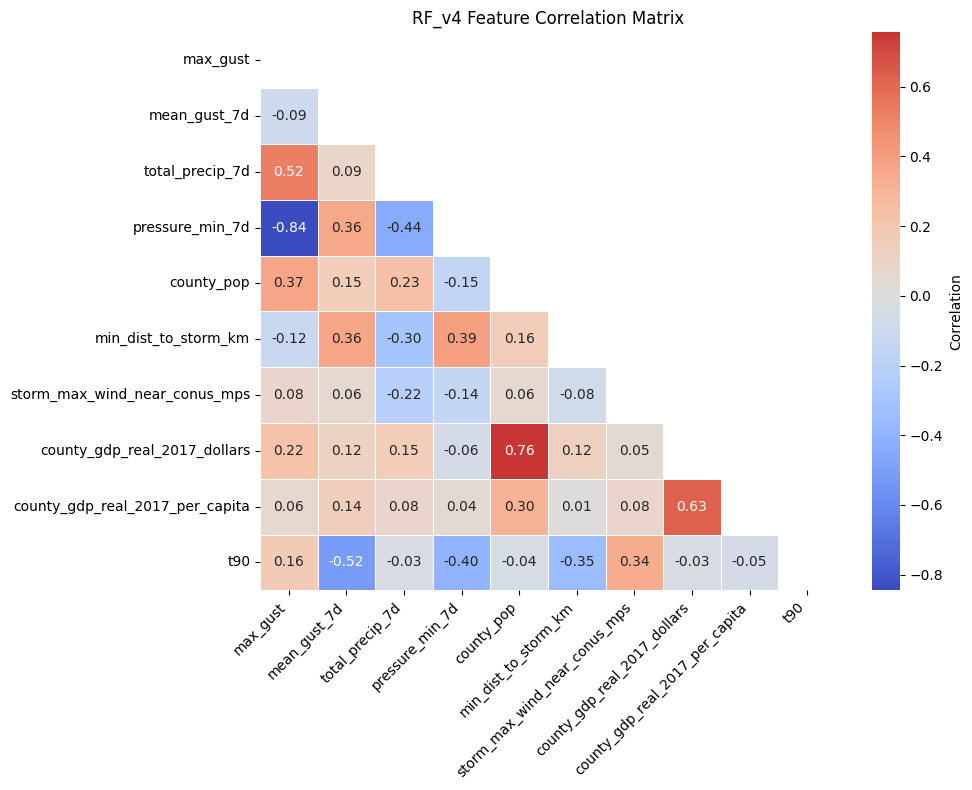

In [15]:
import seaborn as sns

corr_cols = features_v4 + ["t90"]
corr = event_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("RF_v4 Feature Correlation Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**HYPERPARAMETER TUNING**

Best params found:

***[fill in later]***

In [17]:
# -----------------------
# RF_v4: sensitivity to number of trees
# -----------------------

tree_grid = [100, 200, 500]

results_estimators = []

for n_trees in tree_grid:
    print(f"\nRunning RF_v4 with n_estimators = {n_trees}")
    
    # Rebuild model with different number of trees
    model_temp = Pipeline([
        ("preprocess", preprocess),
        ("rf", RandomForestRegressor(
            n_estimators=n_trees,
            max_depth=None,
            min_samples_leaf=3,
            random_state=42
        ))
    ])
    
    preds_temp, fold_df_temp, mae_temp, rmse_temp = evaluate_logo_global(
        model_temp, X, y, groups
    )
    
    print(f"Global MAE: {mae_temp:.2f}")
    print(f"Global RMSE: {rmse_temp:.2f}")
    
    results_estimators.append({
        "n_estimators": n_trees,
        "MAE": mae_temp,
        "RMSE": rmse_temp
    })

results_estimators_df = pd.DataFrame(results_estimators)

print("\nSummary:")
print(results_estimators_df)


Running RF_v4 with n_estimators = 100
Global MAE: 104.39
Global RMSE: 130.34

Running RF_v4 with n_estimators = 200
Global MAE: 104.23
Global RMSE: 129.67

Running RF_v4 with n_estimators = 500
Global MAE: 107.11
Global RMSE: 132.63

Summary:
   n_estimators         MAE        RMSE
0           100  104.392776  130.338182
1           200  104.227602  129.669037
2           500  107.114615  132.628778


^purely the number of trees doesn't matter much. adding more is worse.

Now for more params:

In [18]:
# -----------------------
# RF_v4 hyperparameter grid
# -----------------------

param_grid = []

for n_est in [100, 200, 500]:
    for leaf in [2, 3, 5, 8]:
        for mf in [0.5, 0.75, 1.0]:
            param_grid.append({
                "n_estimators": n_est,
                "min_samples_leaf": leaf,
                "max_features": mf
            })

print("Total configs:", len(param_grid))

Total configs: 36


In [19]:
def evaluate_rf_config(params, X, y, groups):
    logo = LeaveOneGroupOut()
    
    preds = np.full(len(y), np.nan)
    
    for train_idx, test_idx in logo.split(X, y, groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        
        model = Pipeline([
            ("preprocess", preprocess),
            ("rf", RandomForestRegressor(
                n_estimators=params["n_estimators"],
                min_samples_leaf=params["min_samples_leaf"],
                max_features=params["max_features"],
                random_state=42
            ))
        ])
        
        model.fit(X_train, y_train)
        preds[test_idx] = model.predict(X_test)
    
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    
    return mae, rmse

In [20]:
results = []

for i, params in enumerate(param_grid):
    print(f"{i+1}/{len(param_grid)}", params)
    
    mae, rmse = evaluate_rf_config(params, X, y, groups)
    
    results.append({
        **params,
        "MAE": mae,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results).sort_values("MAE")

print("\nTop 10 configurations:")
print(results_df.head(10))

1/36 {'n_estimators': 100, 'min_samples_leaf': 2, 'max_features': 0.5}
2/36 {'n_estimators': 100, 'min_samples_leaf': 2, 'max_features': 0.75}
3/36 {'n_estimators': 100, 'min_samples_leaf': 2, 'max_features': 1.0}
4/36 {'n_estimators': 100, 'min_samples_leaf': 3, 'max_features': 0.5}
5/36 {'n_estimators': 100, 'min_samples_leaf': 3, 'max_features': 0.75}
6/36 {'n_estimators': 100, 'min_samples_leaf': 3, 'max_features': 1.0}
7/36 {'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': 0.5}
8/36 {'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': 0.75}
9/36 {'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': 1.0}
10/36 {'n_estimators': 100, 'min_samples_leaf': 8, 'max_features': 0.5}
11/36 {'n_estimators': 100, 'min_samples_leaf': 8, 'max_features': 0.75}
12/36 {'n_estimators': 100, 'min_samples_leaf': 8, 'max_features': 1.0}
13/36 {'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 0.5}
14/36 {'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 0.

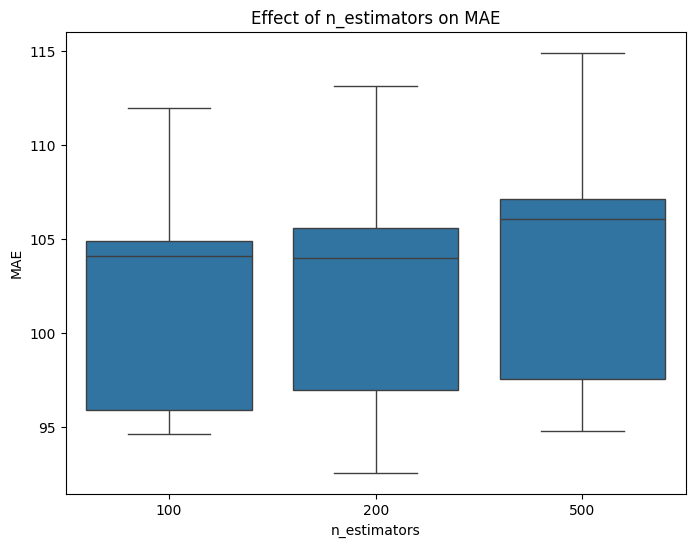

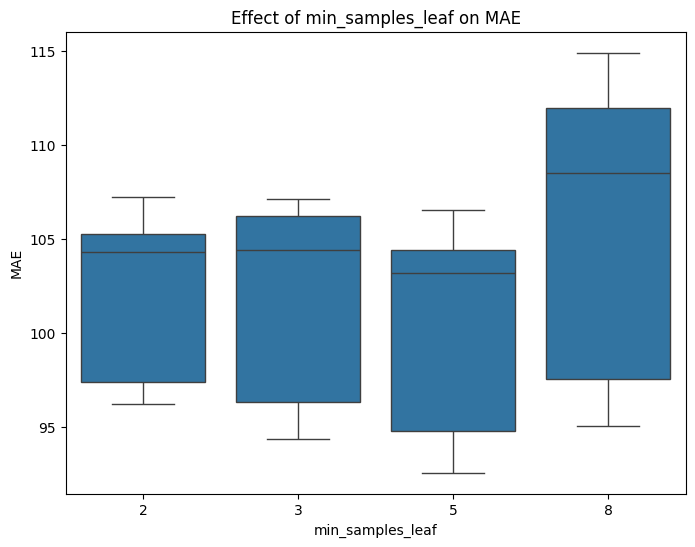

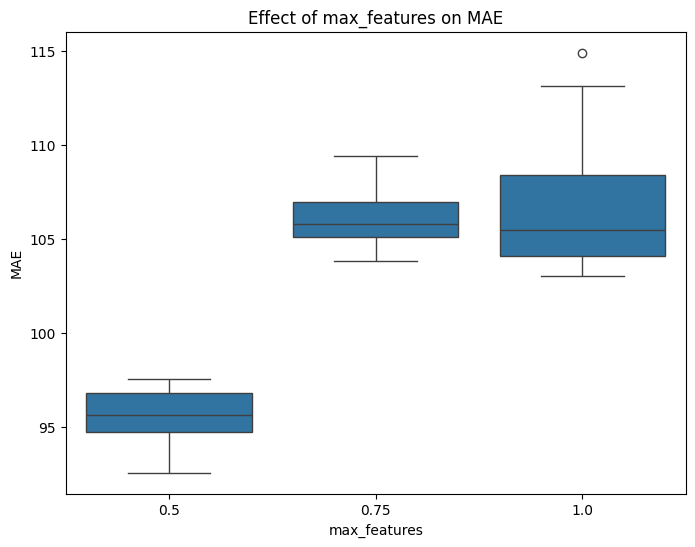

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(data=results_df, x="n_estimators", y="MAE")
plt.title("Effect of n_estimators on MAE")
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(data=results_df, x="min_samples_leaf", y="MAE")
plt.title("Effect of min_samples_leaf on MAE")
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(data=results_df, x="max_features", y="MAE")
plt.title("Effect of max_features on MAE")
plt.show()